In [2]:
!pip install scipy h5py opencv-python


### Data Loader and Density Map Generator

In [3]:
import os
import cv2
import numpy as np
import scipy.io
from tensorflow.keras.utils import Sequence
from tensorflow import keras
from keras import layers
from PIL import Image

def load_annotations(mat_path):
    mat = scipy.io.loadmat(mat_path)
    points = mat["annPoints"]  # shape: (N, 2)
    return points

def generate_density_map(image_shape, points, sigma=15):
    h, w = image_shape
    density = np.zeros((h, w), dtype=np.float32)

    for point in points:
        x, y = int(min(w-1, point[0])), int(min(h-1, point[1]))
        density[y, x] += 1

    density = cv2.GaussianBlur(density, (0, 0), sigma)
    return density


### Mount Google Drive if using Colab

In [4]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Custom Dataset Generator (for UCF-QNRF)

In [5]:
import os
import cv2
import numpy as np
import scipy.io
from tensorflow.keras.utils import Sequence
from tensorflow import keras
from keras import layers
from PIL import Image

def load_annotations(mat_path):
    mat = scipy.io.loadmat(mat_path)
    points = mat["annPoints"]  # shape: (N, 2)
    return points

def generate_density_map(image_shape, points, sigma=15):
    h, w = image_shape
    density = np.zeros((h, w), dtype=np.float32)

    for point in points:
        x, y = int(min(w-1, point[0])), int(min(h-1, point[1]))
        density[y, x] += 1

    density = cv2.GaussianBlur(density, (0, 0), sigma)
    return density

class UCFQNRFDataset(Sequence):
    def __init__(self, data_dir, img_size=(256, 256), batch_size=4):
        self.img_paths = [f for f in os.listdir(data_dir) if f.endswith(".jpg")]
        self.data_dir = data_dir
        self.img_size = img_size
        self.batch_size = batch_size

    def __len__(self):
        return len(self.img_paths) // self.batch_size

    def __getitem__(self, idx):
        batch_paths = self.img_paths[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = []
        batch_density = []

        for fname in batch_paths:
            img_path = os.path.join(self.data_dir, fname)
            # Correctly construct the mat path assuming they are in the same directory
            mat_fname = fname.replace(".jpg", "_ann.mat")
            mat_path = os.path.join(self.data_dir, mat_fname)

            img = Image.open(img_path).convert("RGB").resize(self.img_size)
            img = np.array(img) / 255.0

            points = load_annotations(mat_path)
            scale_x = self.img_size[0] / Image.open(img_path).width
            scale_y = self.img_size[1] / Image.open(img_path).height
            points_scaled = [[x * scale_x, y * scale_y] for x, y in points]

            density = generate_density_map(self.img_size, points_scaled)

            batch_images.append(img)
            batch_density.append(np.expand_dims(density, axis=-1))

        return np.array(batch_images), np.array(batch_density)

## U‑Net Model Definition

In [6]:
def build_unet(input_shape):
    inputs = keras.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPool2D()(c1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPool2D()(c2)

    # Bottleneck
    b = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)

    # Decoder
    u2 = layers.UpSampling2D()(b)
    u2 = layers.Concatenate()([u2, c2])
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(u2)

    u1 = layers.UpSampling2D()(c3)
    u1 = layers.Concatenate()([u1, c1])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    output = layers.Conv2D(1, 1, activation='relu')(c4)

    return keras.Model(inputs, output)


## Training Loop

In [9]:
# Setup
data_dir = "//content/drive/MyDrive/Assignment 8/UCF-QNRF_ECCV18/Train"
input_shape = (256, 256, 3)
batch_size = 16

train_gen = UCFQNRFDataset(data_dir, img_size=input_shape[:2], batch_size=batch_size)

# Build and compile model
model = build_unet(input_shape)
model.compile(optimizer='adam', loss='mse')  # or use MAE

# Train
model.fit(train_gen, epochs=20)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - loss: 0.0018
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 237s 3s/step - loss: 9.9568e-04
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 216s 3s/step - loss: 9.8874e-04
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 212s 3s/step - loss: 0.0015
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 218s 3s/step - loss: 9.7887e-04
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - loss: 0.0010
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 214s 3s/step - loss: 0.0011
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - loss: 8.6087e-04
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 217s 3s/step - loss: 0.0012
Epoch 10/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 213s 3s/step - loss: 0.0011
Epoch 11/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 203s 3s/step - loss: 7.9383e-04
Epoch 12/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - loss: 9.7533e-04
Epoch 13/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 207s 3s/step - loss: 9.3221e-04
Epoch 14/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - loss: 0.0010
Epoch 15/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 213s

KeyboardInterrupt: 

In [10]:
test_dir = "/content/drive/MyDrive/Assignment 8/UCF-QNRF_ECCV18/Test"
test_gen = UCFQNRFDataset(test_dir, img_size=input_shape[:2], batch_size=1)


## Model Evaluation

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


334/334 ━━━━━━━━━━━━━━━━━━━━ 137s 404ms/step - loss: 5.1906e-04
Test Loss (MSE or MAE): 0.0006278621731325984
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step


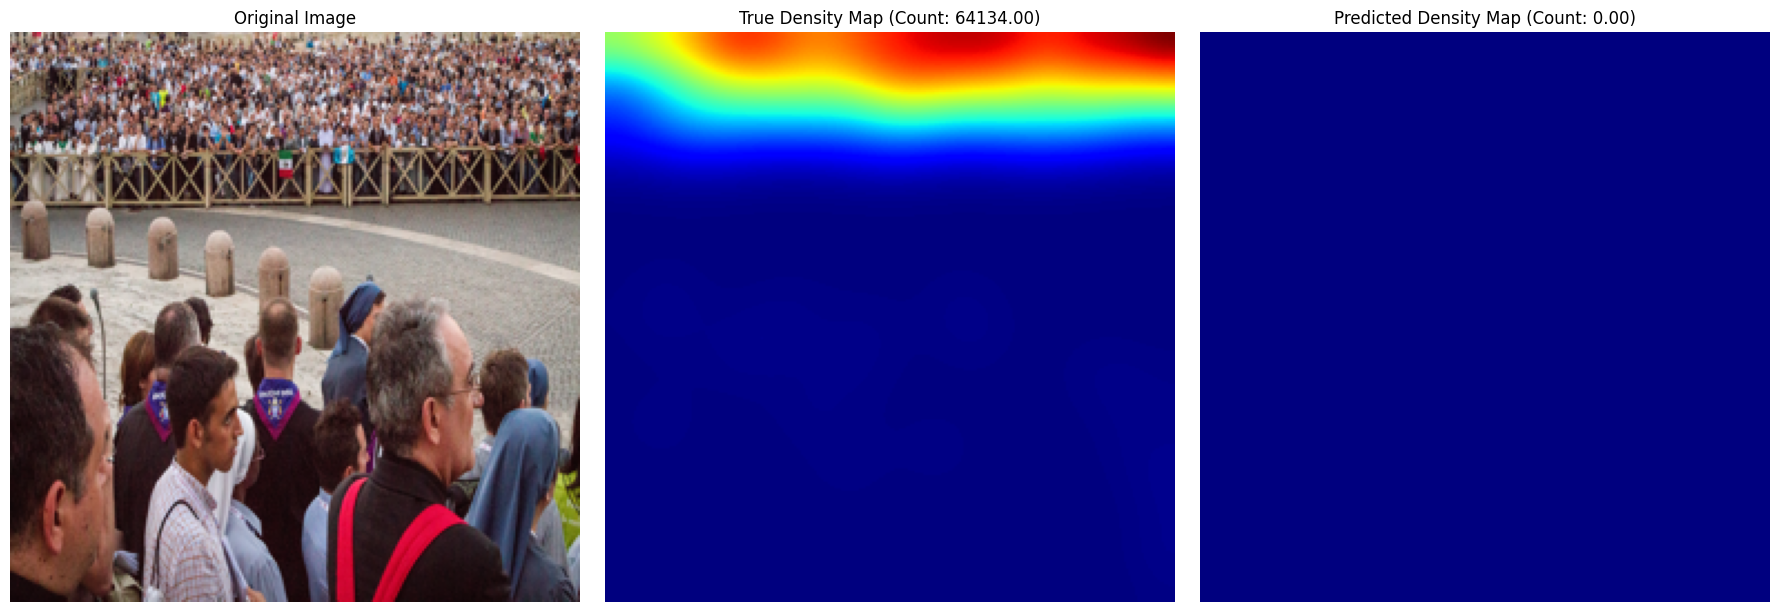

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


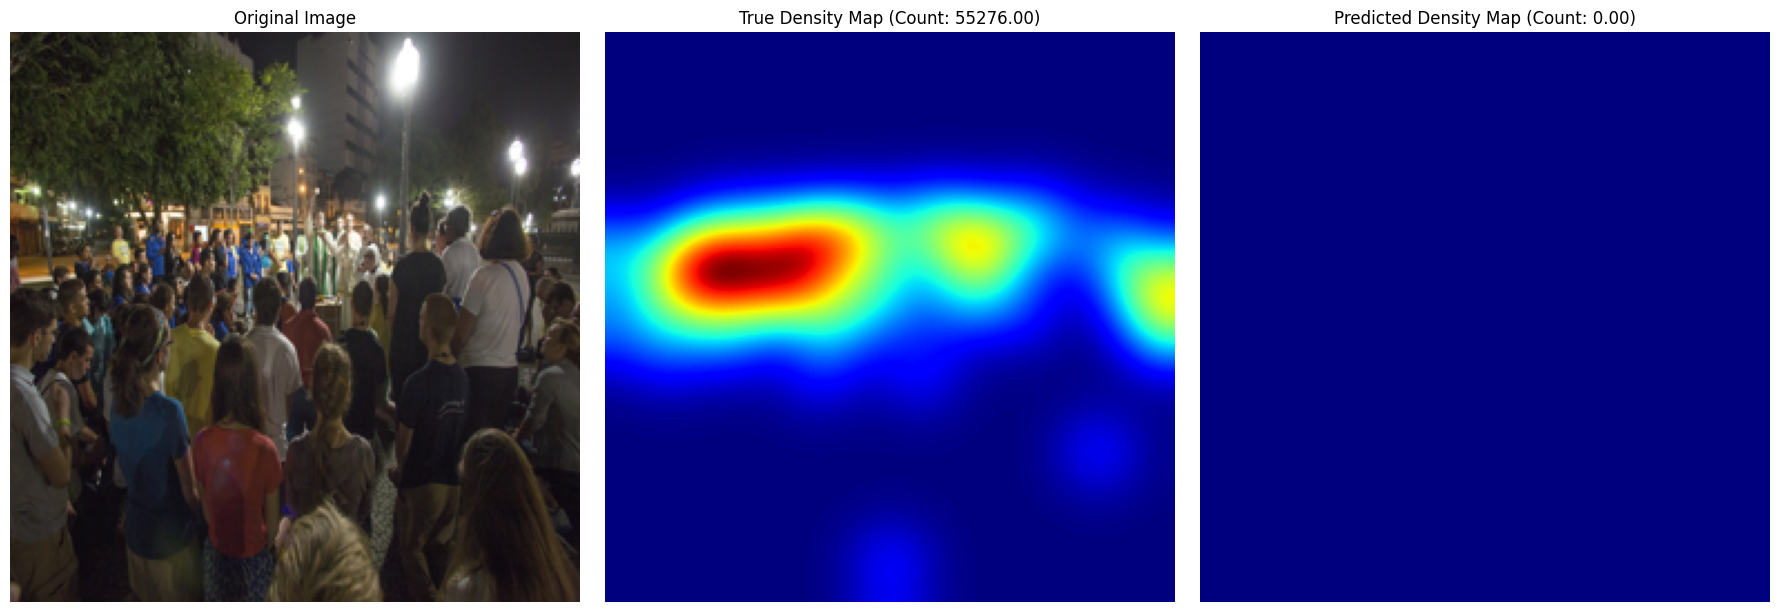

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


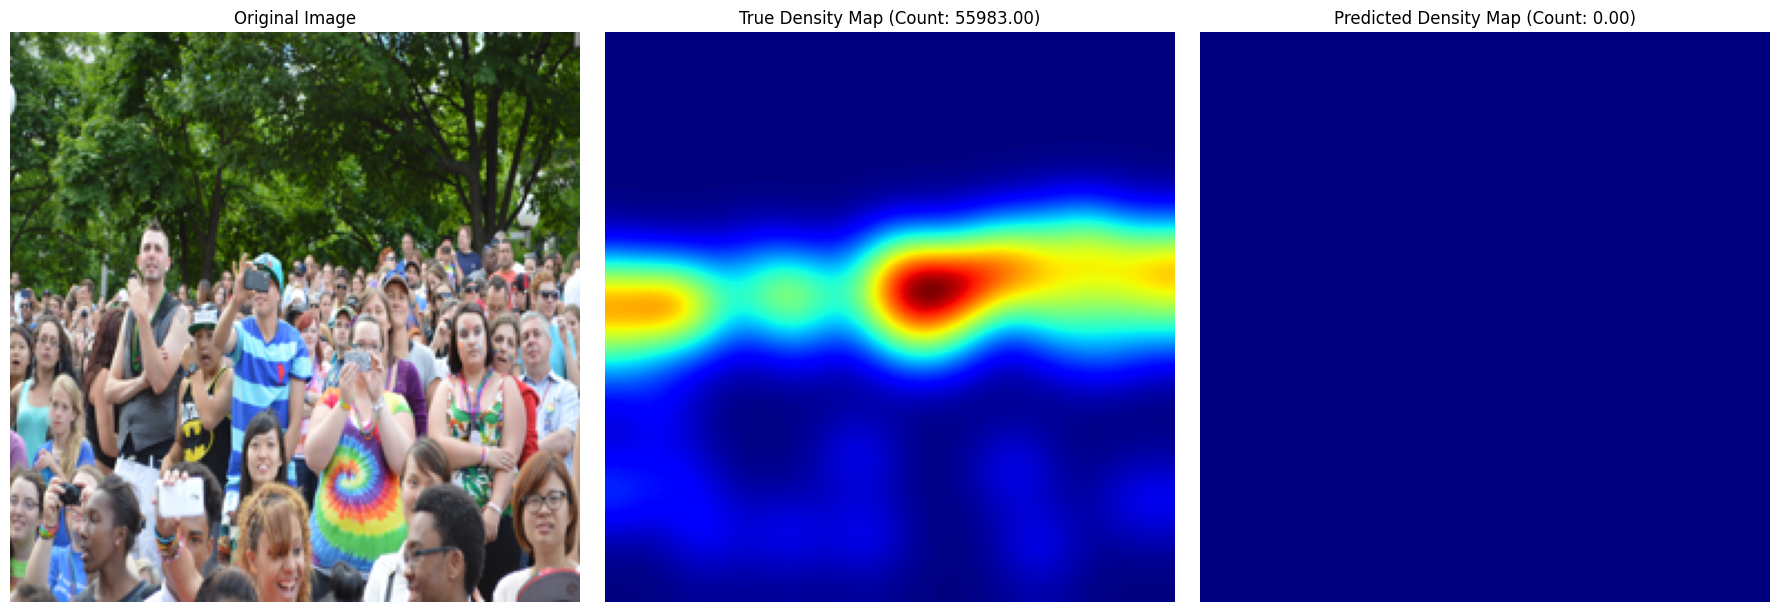

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


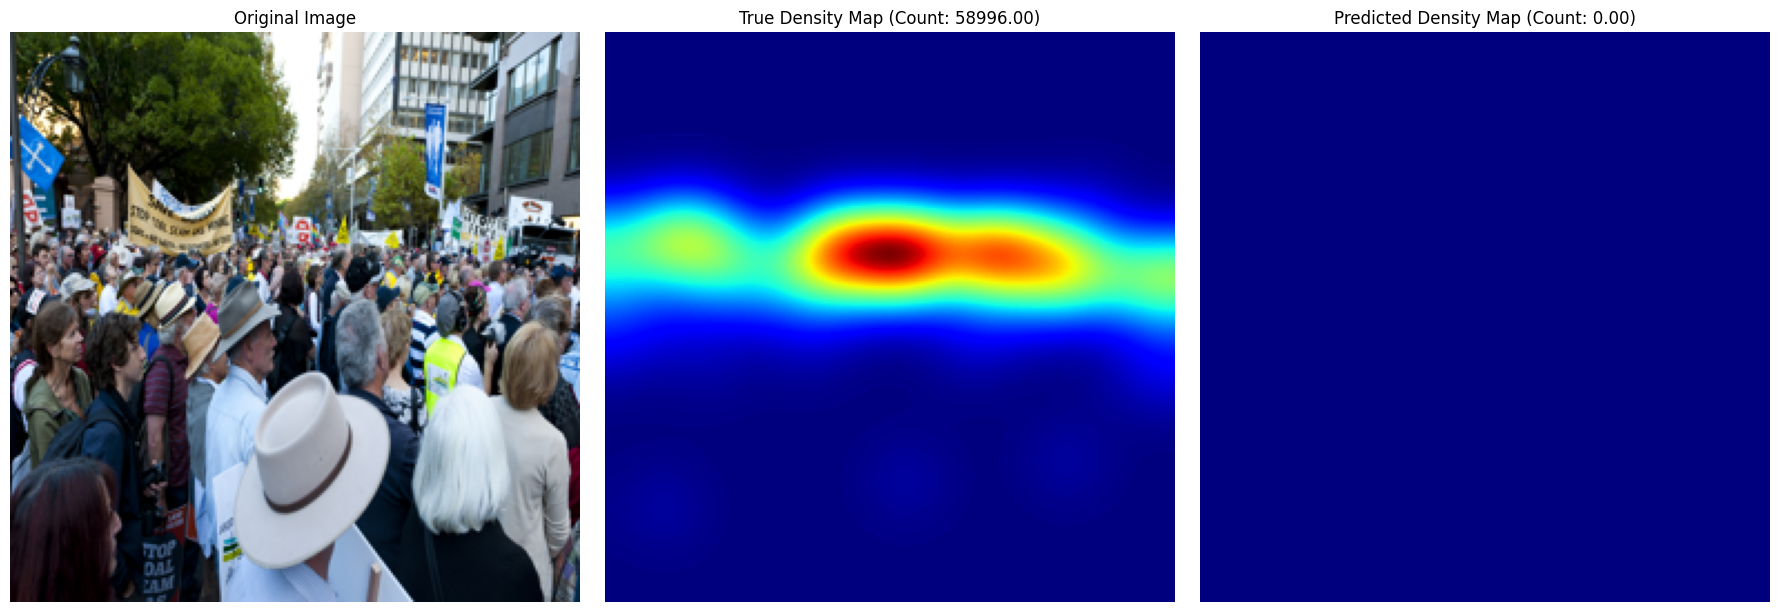

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


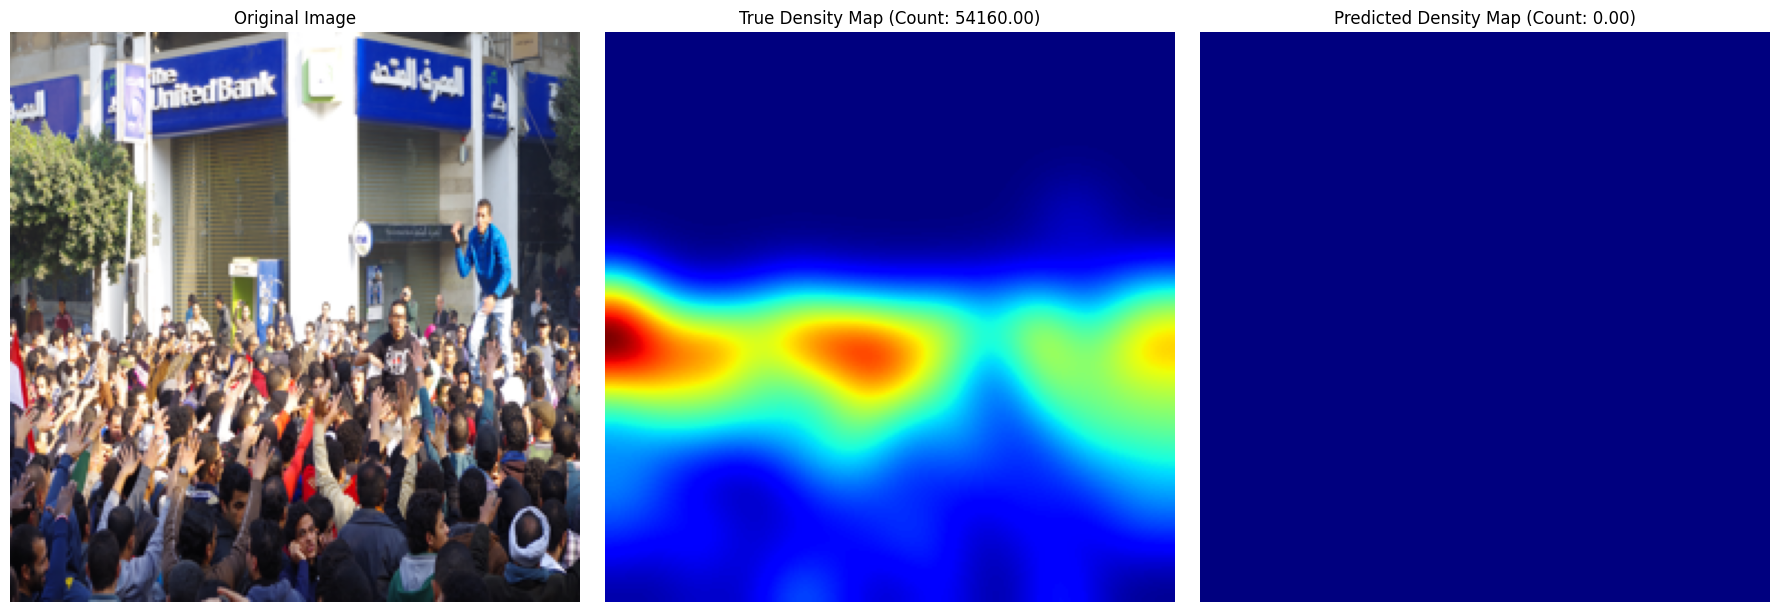

In [11]:

import matplotlib.pyplot as plt

# Evaluate the model on the test data
results = model.evaluate(test_gen)
print(f"Test Loss (MSE or MAE): {results}")

num_visualizations = 5

for i in range(num_visualizations):
    test_image, true_density_map = test_gen[i]

    # Predict the density map
    predicted_density_map = model.predict(test_image)

    # Remove the batch dimension
    test_image = test_image[0]
    true_density_map = true_density_map[0, :, :, 0]
    predicted_density_map = predicted_density_map[0, :, :, 0]

    predicted_count = np.sum(predicted_density_map)
    true_count = np.sum(true_density_map > 0)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(test_image)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_density_map, cmap='jet')
    plt.title(f"True Density Map (Count: {true_count:.2f})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(predicted_density_map, cmap='jet')
    plt.title(f"Predicted Density Map (Count: {predicted_count:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()